# FDS/IDS Assignment

## Load Data and Drop Duplicates

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

file_path = "data/UCMF.xls"
df = pd.read_excel(file_path)

print(f"Original Shape: {df.shape}")

df = df.drop_duplicates()
print(f"Drop duplicates shape: {df.shape}")

Original Shape: (17873, 21)
Drop duplicates shape: (17873, 21)


## Plot Dropped Function

In [3]:
import matplotlib.pyplot as plt

def plot_step(df, mask_removed, x_col, y_col, title, filename):
    df_in = df.copy()
    plt.figure(figsize=(10, 6))
    
    # Plot Kept
    kept = df_in[~mask_removed]
    plt.scatter(kept[x_col], kept[y_col], c='blue', alpha=0.3, s=10, label='Kept')
    
    # Plot Removed
    removed = df_in[mask_removed]
    plt.scatter(removed[x_col], removed[y_col], c='red', alpha=0.6, s=15, marker='x', label='Removed')
    
    plt.title(f"{title}\n({len(removed)} removed)")
    plt.xlabel('Age (Years)')
    plt.ylabel(y_col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

## Peso, Altura, Idade, IMC and Sexo

Age fixed shape: (16255, 23)
0         2.40
1         2.40
3         2.40
4        13.00
5         4.00
         ...  
17867     3.25
17868     2.90
17869     2.90
17870    15.20
17872    16.00
Name: Peso, Length: 16255, dtype: float64


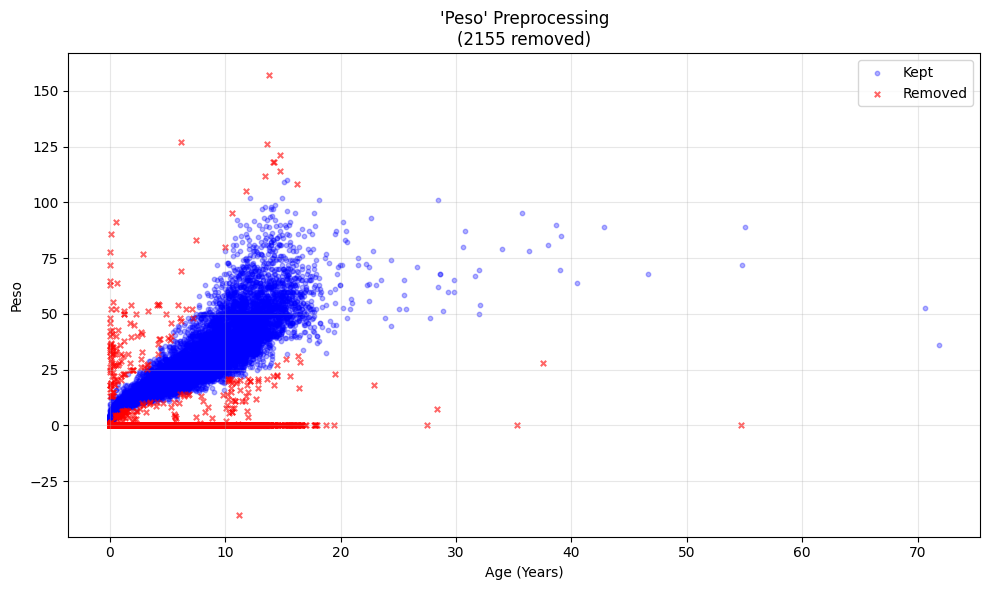

Peso age group outliers removed shape: (14100, 25)
Altura age group outliers removed shape: (14100, 25)


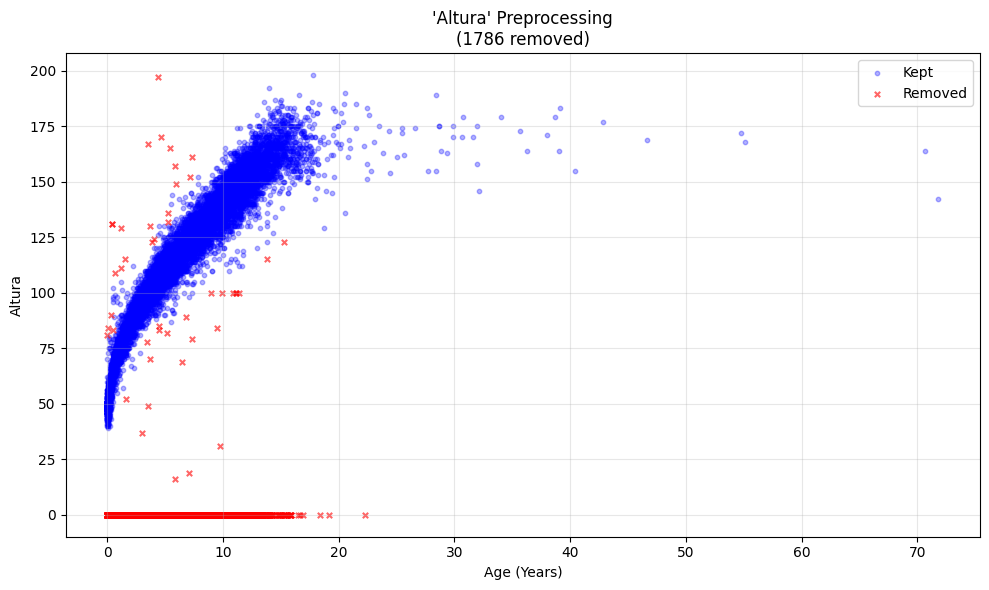

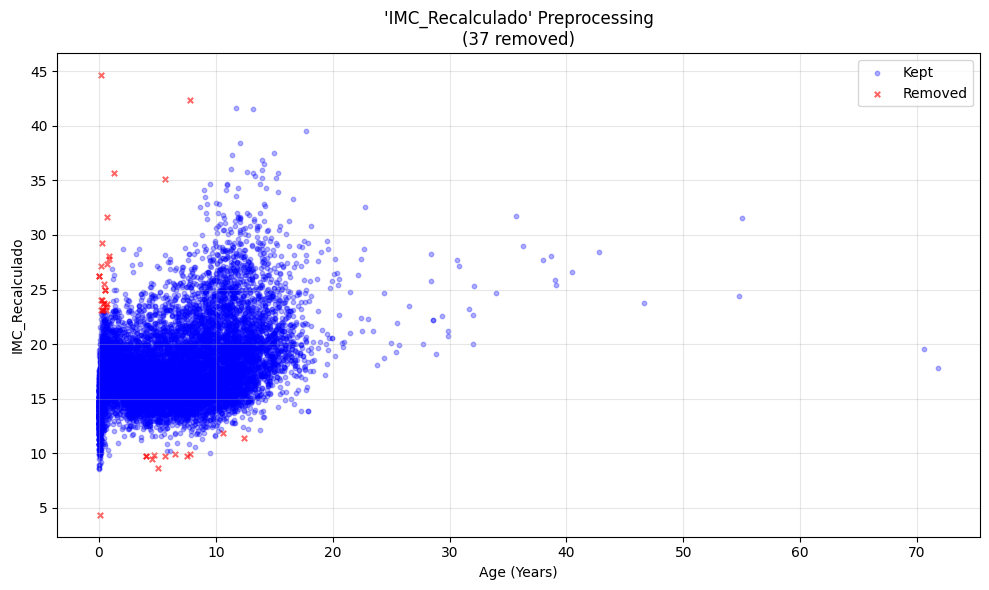

Final shape after IMC filtering: (12277, 26)
SEXO
M                6509
F                4764
Masculino         413
Indeterminado     366
Feminino          167
masculino          55
Name: count, dtype: int64
Final shape: (11908, 26)


In [4]:
import pandas as pd

# turn to numeric all weights, heights and ages, np.nan those you cannot
for col in ['Peso', 'IDADE', 'Altura']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


# calculate age based on atendimento and DN
df['Idade_Calc'] = (pd.to_datetime(df['Atendimento'], dayfirst=True, format='%d/%m/%y', errors='coerce') - 
                    pd.to_datetime(df['DN'], dayfirst=True, format='%d/%m/%y', errors='coerce')).dt.days / 365.25

# if cases have small error or we don't have value, we trust in
# the calculated age, else, we use the values provided
error_condition = abs(df['Idade_Calc'] - df['IDADE']) > 1.0
df['Idade'] = np.where(error_condition | df['Idade_Calc'].isna(), df['IDADE'], df['Idade_Calc'])

# remove remaining invalid values
df = df[df['Idade'] >= 0]

print(f"Age fixed shape: {df.shape}")

# define filter to remove invalid values
peso_mask = (
    (df['Peso'] <= 0) |
    (df['Peso'] >= 250) |
    (df['Peso'].isna())
)

# ultra conservative weights chosen to account for people with diseases
# based on 1st percentile values from WHO (~3 SD), Extreme Low Birth Weight 
# newborn babies get "ignored" here
def get_min_viable_weight(age):
    if age < 1: return 1.5  # Premature/Newborn
    if age < 3: return 7.0  # Toddler
    if age < 6: return 10.0 # Young Child
    if age < 10: return 15.0 # School age
    if age < 14: return 22.0 # Pre-teen
    return 30.0 # Teen/Adult

# apply minimum weight filter
df['Min_Weight'] = df['Idade'].apply(get_min_viable_weight)
peso_mask |= df['Peso'] < df['Min_Weight']

# remove outliers by age group, use double the iqr for upper (to only target percentiles
# 97-99 of each age group, which are most likely to be errors) multiplier since
# we are in medical context and obesity is expected, only obvious errors removed
# Assymetric Ranges used because of average patient profile
df['Grupo_Idade'] = df['IDADE'].round()

groups_age = df.groupby('Grupo_Idade')['Peso']

Q1 = groups_age.transform(lambda x: x.quantile(0.25))
Q3 = groups_age.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower_bound = Q1 - 1.0 * IQR
upper_bound = Q3 + 3.0 * IQR
print(IQR)
peso_mask |= (df['Peso'] < lower_bound) | (df['Peso'] > upper_bound)

plot_step(df, peso_mask, "Idade", "Peso", "'Peso' Preprocessing", "peso_removal.png")

df = df[~peso_mask].copy()
print(f"Peso age group outliers removed shape: {df.shape}")

# remove nonesensical heights (less than 15cm and more than 250cm)
altura_mask = (
    (df['Altura'] < 15) |
    (df['Altura'] > 250) |
    (df['Altura'].isna())
) 

# same logic as above, value of 2.0 utilised for both upper and lower limit,
# a good meld between solving for outliers while maintaining variance in the populations
groups_altura = df.groupby('Grupo_Idade')['Altura']

Q1 = groups_altura.transform(lambda x: x.quantile(0.25))
Q3 = groups_altura.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower_bound = Q1 - 2.5 * IQR
upper_bound = Q3 + 2.5 * IQR

altura_mask |= ((df['Altura'] < lower_bound) | (df['Altura'] > upper_bound))
print(f"Altura age group outliers removed shape: {df.shape}")

plot_step(df, altura_mask, "Idade", "Altura", "'Altura' Preprocessing", "altura_removal.png")
df = df[~altura_mask].copy()

df['IMC_Recalculado'] = df['Peso'] / ((df['Altura'] / 100) ** 2)

# True for rows to remove
def get_imc_validity_mask(df):
    mask = pd.Series(False, index=df.index)
    
    # Infants (< 1 year): IMC 6-23
    mask |= (df['Idade'] < 1) & ((df['IMC_Recalculado'] < 6) | (df['IMC_Recalculado'] > 23))
    
    # Toddlers/Kids (1-10 years): IMC 10-35
    mask |= (df['Idade'] >= 1) & (df['Idade'] < 10) & (
        (df['IMC_Recalculado'] < 10) | (df['IMC_Recalculado'] > 35)
    )
    
    # Teens/Adults (10+ years): IMC 12-50
    mask |= (df['Idade'] >= 10) & (
        (df['IMC_Recalculado'] < 12) | (df['IMC_Recalculado'] > 50)
    )
    
    return mask

IMC_mask = get_imc_validity_mask(df)

plot_step(df, IMC_mask, "Idade", "IMC_Recalculado", "'IMC_Recalculado' Preprocessing", "imc_removal.png")
df = df[~IMC_mask].copy()

df['IMC'] = df['IMC_Recalculado']
print(f"Final shape after IMC filtering: {df.shape}")

print(df['SEXO'].value_counts())

# all possible gender mappings
sexo_map = {
    'M': 1, 'Masculino': 1, 'masculino': 1,
    'F': 0, 'f': 0, 'Feminino': 0, 'feminino': 0
}

# apply map, values not defined become np.nan
df['SEXO'] = df['SEXO'].map(sexo_map)

# drop nan
df = df.dropna(subset=['SEXO'])

print(f"Final shape: {df.shape}")

## Drop and Organize Columns

In [5]:
print(df.columns)

df = df.drop(columns=['ID', 'Atendimento', 'DN', 'IDADE', 'Convenio', 'Idade_Calc', 'IMC_Recalculado'])

Index(['ID', 'Peso', 'Altura', 'IMC', 'Atendimento', 'DN', 'IDADE', 'Convenio',
       'PULSOS', 'PA SISTOLICA', 'PA DIASTOLICA', 'PPA', 'NORMAL X ANORMAL',
       'B2', 'SOPRO', 'FC', 'HDA 1', 'HDA2', 'SEXO', 'MOTIVO1', 'MOTIVO2',
       'Idade_Calc', 'Idade', 'Min_Weight', 'Grupo_Idade', 'IMC_Recalculado'],
      dtype='object')


## PA Sistolica, PA Diastolica and FC

Shape after negative or null removal: (7091, 19)


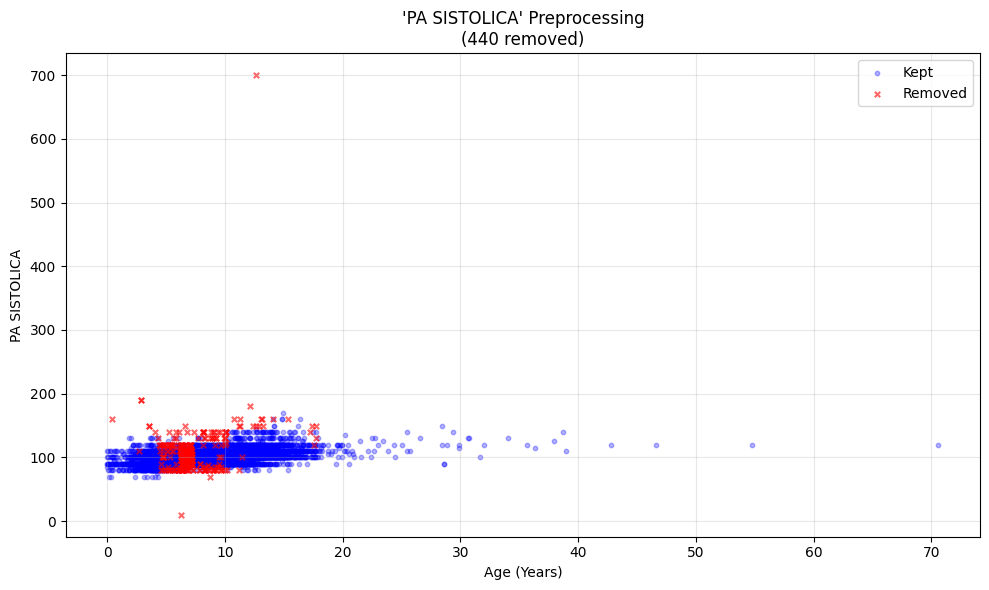

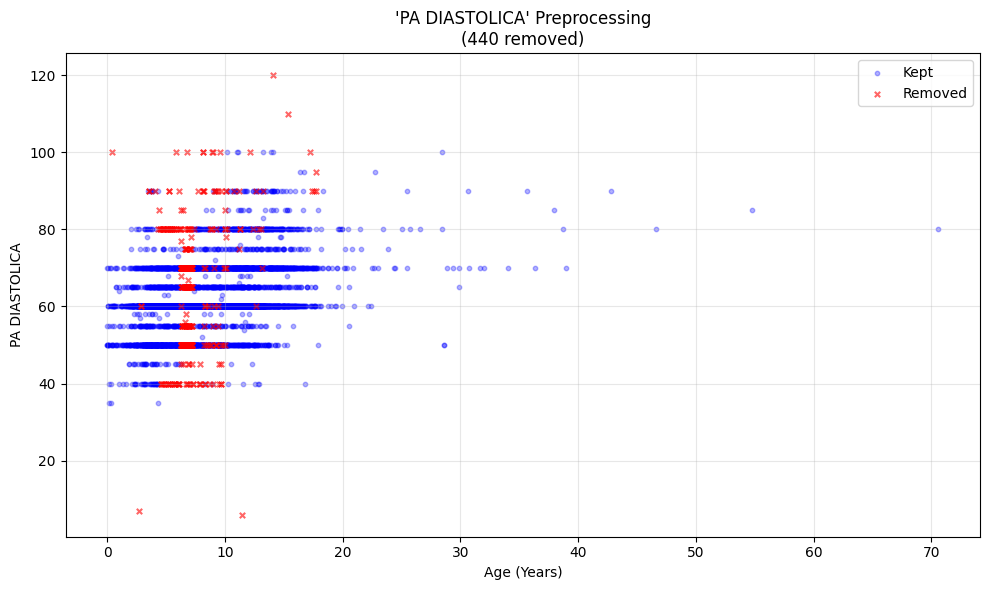

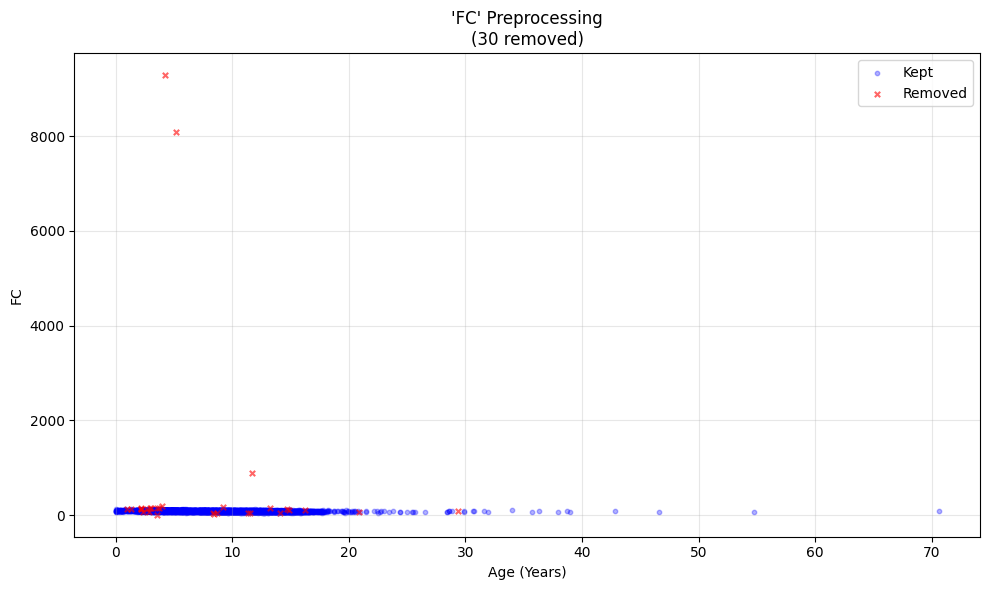

In [6]:
cols_vitals = ['PA SISTOLICA', 'PA DIASTOLICA', 'FC']
for col in cols_vitals:
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # negative/null values impossible for living beings
    df = df[df[col] > 0]

print(f"Shape after negative or null removal: {df.shape}")

bp_mask = pd.Series(False, index=df.index)

# cannot have inverted bp or very close
bp_mask |= (df['PA DIASTOLICA'] > df['PA SISTOLICA'])
bp_mask |= ((df['PA SISTOLICA'] - df['PA DIASTOLICA']) < 10)

# hard medical limits for blood pressure
bp_mask |= (
    (df['PA SISTOLICA'] > 320) | (df['PA SISTOLICA'] < 40) |
    (df['PA DIASTOLICA'] > 200) | (df['PA DIASTOLICA'] < 20)
)

groups = df.groupby('Grupo_Idade')['PA SISTOLICA']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)
    
bp_mask |= ((df['PA SISTOLICA'] < lower) | (df['PA SISTOLICA'] > upper))

groups = df.groupby('Grupo_Idade')['PA DIASTOLICA']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)
    
bp_mask |= ((df['PA DIASTOLICA'] < lower) | (df['PA DIASTOLICA'] > upper))

plot_step(df, bp_mask, 'Idade', 'PA SISTOLICA', "'PA SISTOLICA' Preprocessing", "sist_removal.png")
plot_step(df, bp_mask, 'Idade', 'PA DIASTOLICA', "'PA DIASTOLICA' Preprocessing", "diast_removal.png")

df = df[~bp_mask].copy()

# hard coded heart frequency limits
fc_mask = (df['FC'] > 300) | (df['FC'] < 25)

groups = df.groupby('Grupo_Idade')['FC']
    
Q1 = groups.transform(lambda x: x.quantile(0.25))
Q3 = groups.transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

# higher fluctuations possible here
lower = Q1 - 2.0 * IQR  # Allow lower drops (shock/hypotension)
upper = Q3 + 3.5 * IQR  # Allow massive spikes (hypertension/tachycardia)

fc_mask |= ((df['FC'] < lower) | (df['FC'] > upper))

plot_step(df, fc_mask, 'Idade', 'FC', "'FC' Preprocessing", "fc_removal.png")
df = df[~fc_mask].copy()

## PULSOS, PPA, B2, SOPRO, HDA and MOTIVO

In [7]:
# unify all 'SOPRO' types
df['SOPRO'] = df['SOPRO'].str.lower().str.strip()

def multi_column_one_hot(df, prefix, cols_to_combine):
    """
    Creates binary columns for unique values found across multiple columns.
    Example: Combines HDA1 and HDA2 into HDA_Dispneia, HDA_Dor, etc.
    """
    # 1. Get all unique values across the specified columns
    unique_values = set()
    for col in cols_to_combine:
        unique_values.update(df[col].dropna().unique())
    
    # 2. Create a new binary column for each unique value
    for val in unique_values:
        # Create a clean column name (remove spaces/special chars)
        clean_name = str(val).replace(' ', '_').replace('/', '_').replace('-', '')
        col_name = f"{prefix}_{clean_name}"
        
        # Check if value exists in ANY of the target columns
        # result is 1 if present, 0 if not
        mask = df[cols_to_combine].apply(lambda x: val in x.values, axis=1)
        df[col_name] = mask.astype(int)
        
    # 3. Drop the original columns
    df = df.drop(columns=cols_to_combine)
    return df

# Apply to HDA
df = multi_column_one_hot(df, "HDA", ['HDA 1', 'HDA2'])

# Apply to MOTIVO
# Note: MOTIVO has numbers (e.g., "5 - Parecer"). You might want to strip numbers first.
# Optional: Strip "15 - ", "6 - " from start of strings if you want cleaner names
for col in ['MOTIVO1', 'MOTIVO2']:
    df[col] = df[col].astype(str).str.replace(r'^\d+\s*-\s*', '', regex=True)

df = multi_column_one_hot(df, "MOTIVO", ['MOTIVO1', 'MOTIVO2'])

# Grouping rare PULSOS (avoid overfitting)
rare_pulsos = ['Femorais diminuidos', 'Diminuídos']
df.loc[df['PULSOS'].isin(rare_pulsos), 'PULSOS'] = 'Alterado'

# Grouping rare B2 (avoid overfitting)
df.loc[df['B2'] == 'Única', 'B2'] = 'Outro'

cols_to_encode = ['PULSOS', 'PPA', 'B2', 'SOPRO']

# drop_first=True prevents multicollinearity (keeps N-1 columns)
# If using Tree-based models (XGBoost/RandomForest), you can set drop_first=False
df = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, drop_first=True, dtype=int)

print(f"Final shape for ML: {df.shape}")

Final shape for ML: (6621, 57)


## ML Applications

## Visualization

In [63]:
import seaborn as sns
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

num_cols = ['Peso', 'Altura', 'IMC', 'PA SISTOLICA', 'PA DIASTOLICA', 'FC', 'Idade']

summary_stats = df[num_cols].describe().T
summary_stats['IQR'] = summary_stats['75%'] - summary_stats['25%']

print("Univariate Statistical Summary ")
display(summary_stats)

Univariate Statistical Summary 


,count,mean,std,min,25%,50%,75%,max,IQR
Peso,6621.0,33.039284,15.871780,1.90000,20.000000,29.800000,43.000000,110.000000,23.000000
Altura,6621.0,129.970548,23.091010,44.00000,111.000000,131.000000,148.000000,198.000000,37.000000
IMC,6621.0,18.394083,3.698625,9.81405,15.709309,17.559834,20.246151,41.639272,4.536841
PA SISTOLICA,6621.0,100.785682,10.192978,70.00000,90.000000,100.000000,105.000000,170.000000,15.000000
PA DIASTOLICA,6621.0,61.934451,8.041561,35.00000,60.000000,60.000000,65.000000,100.000000,5.000000
FC,6621.0,85.466546,10.903337,48.00000,78.000000,84.000000,92.000000,140.000000,14.000000
Idade,6621.0,8.610915,4.231353,0.00000,5.177276,8.558522,11.416838,70.610000,6.239562


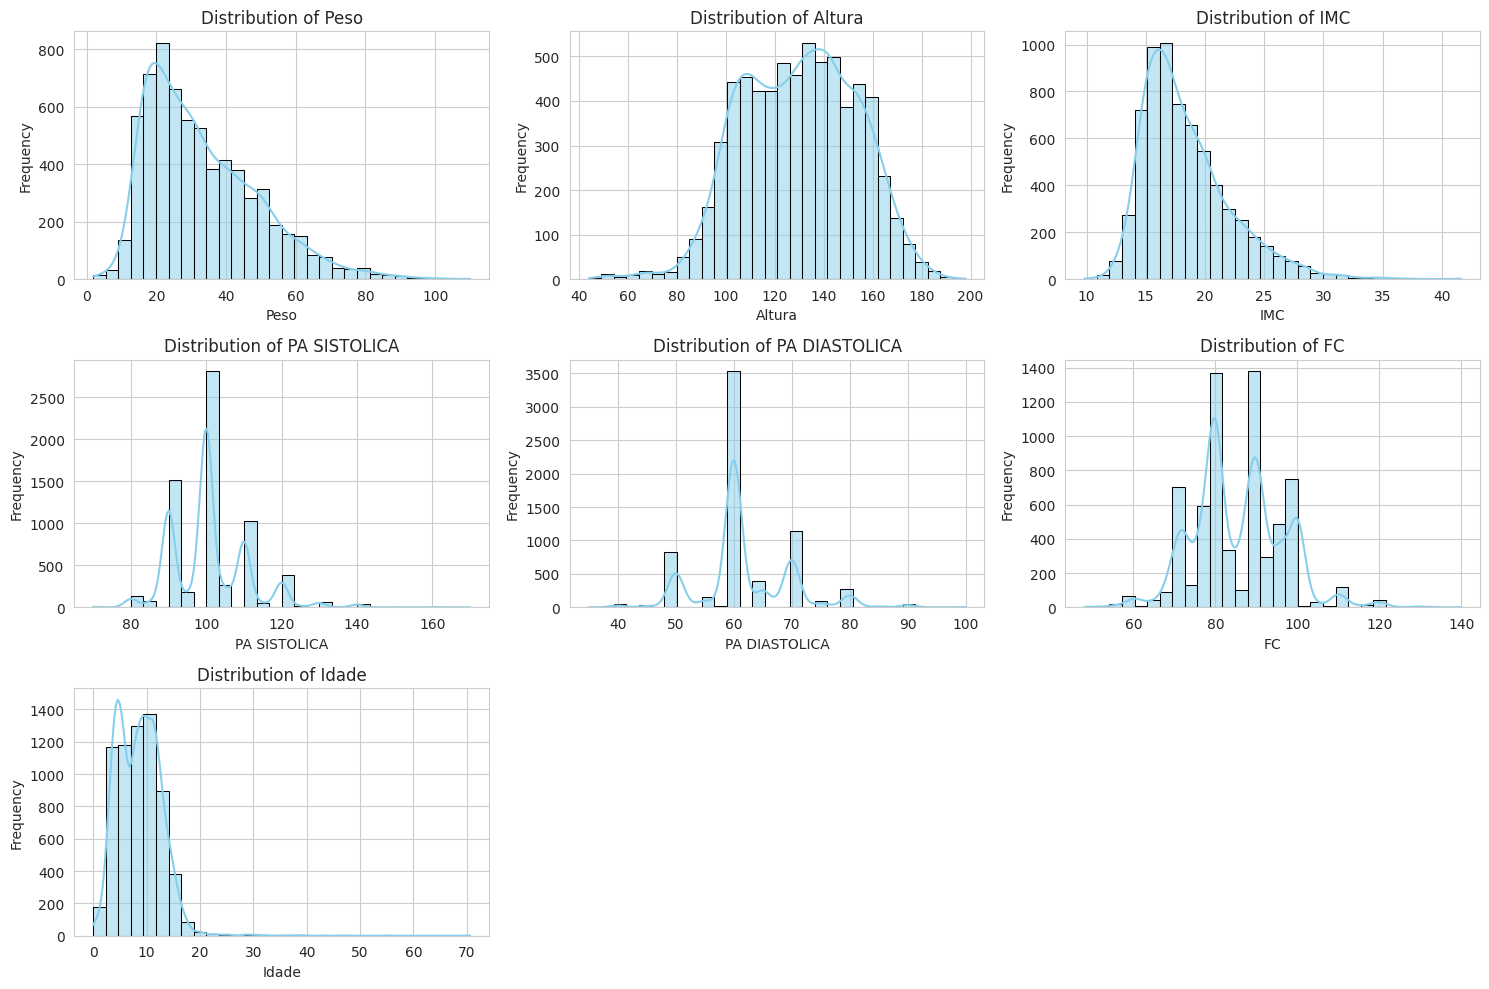

In [64]:
sns.set_style("whitegrid")

# histograms for all numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

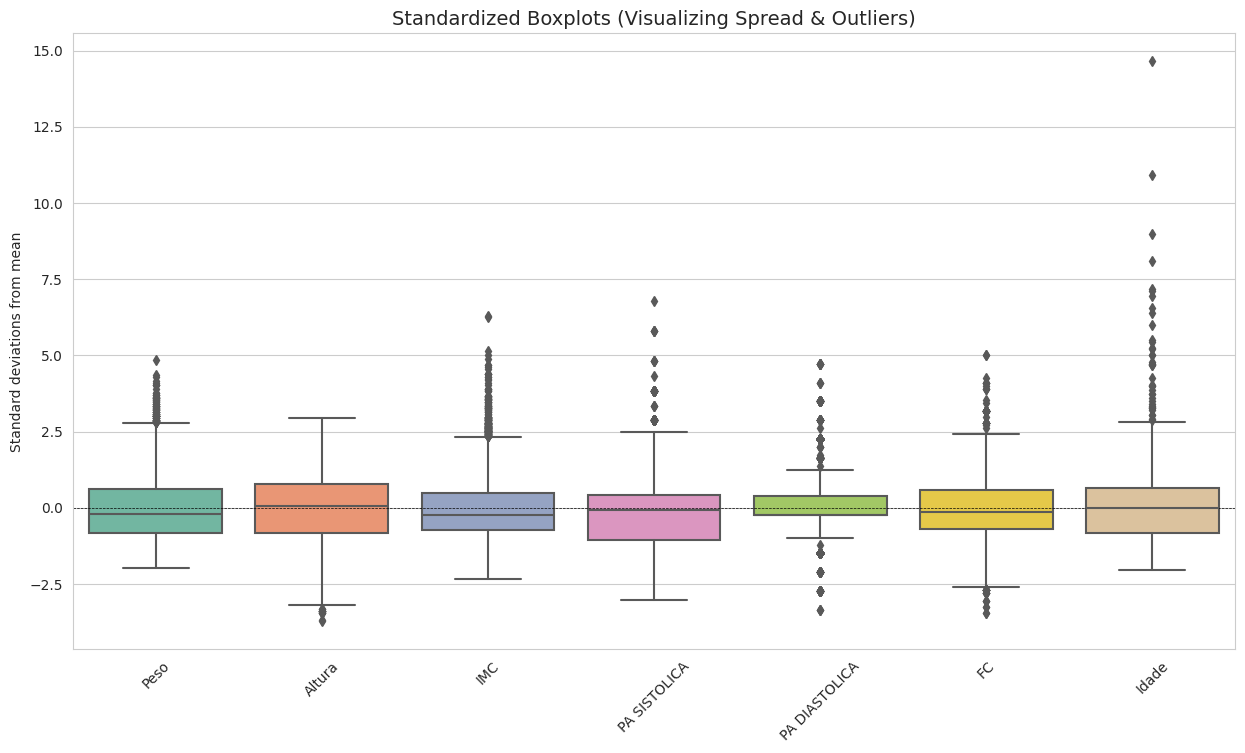

In [65]:
plt.figure(figsize=(15, 8))

# standardize the data temporarily just for this plot so they fit on the same scale
df_std = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

sns.boxplot(data=df_std, palette="Set2")
plt.title('Standardized Boxplots (Visualizing Spread & Outliers)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Standard deviations from mean')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.show()

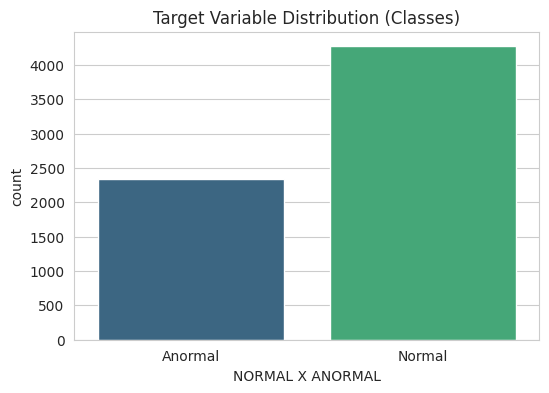

NORMAL X ANORMAL
Normal     64.579552
Anormal    35.420448
Name: proportion, dtype: float64


In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(x='NORMAL X ANORMAL', data=df, palette='viridis')
plt.title('Target Variable Distribution (Classes)')
plt.show()

print(df['NORMAL X ANORMAL'].value_counts(normalize=True) * 100)

## Bivariate Analysis

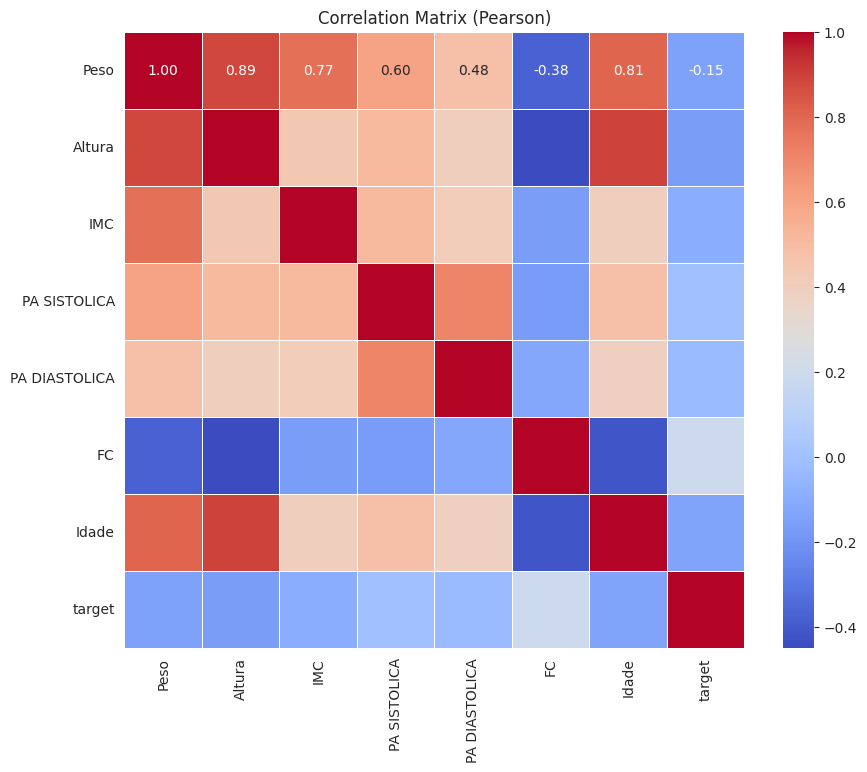

            Peso    Altura     Idade       IMC
Peso    1.000000  0.886158  0.807437  0.772083
Altura  0.886158  1.000000  0.892840  0.434421
Idade   0.807437  0.892840  1.000000  0.395134
IMC     0.772083  0.434421  0.395134  1.000000


In [67]:
target_map = {'Normal': 0, 'Anormal': 1}
df['target'] = df['NORMAL X ANORMAL'].map(target_map)

corr_cols = ['Peso', 'Altura', 'IMC', 'PA SISTOLICA', 'PA DIASTOLICA', 'FC', 'Idade', 'target']

corr_matrix = df[corr_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Pearson)')
plt.show()

growth_cols = ['Peso', 'Altura', 'Idade', 'IMC']
print(df[growth_cols].corr())


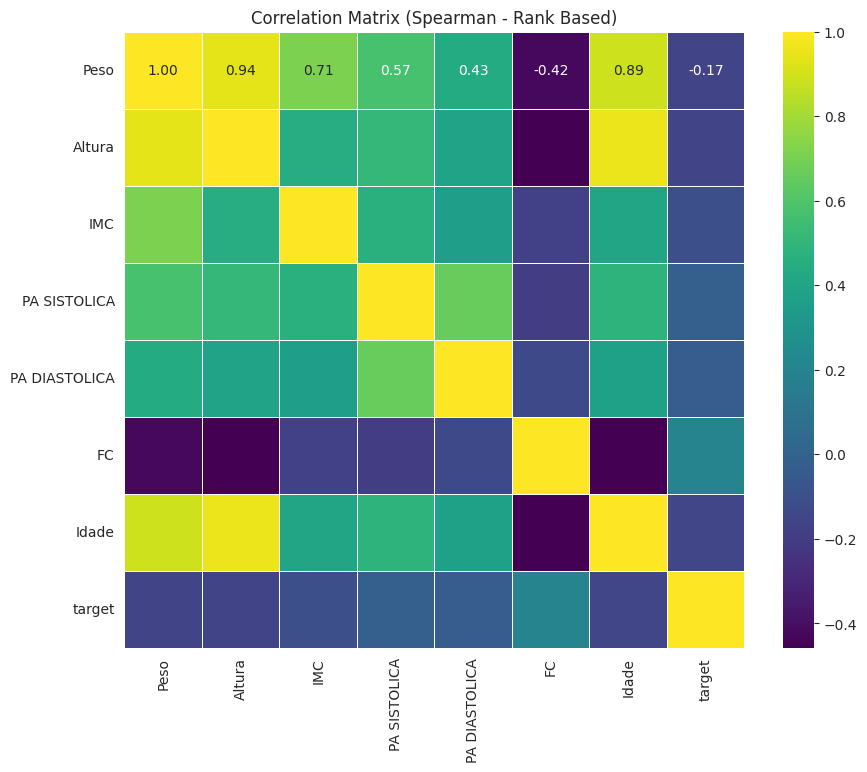

Pearson (Linear) Weight vs BMI: 0.7720828523187487
Spearman (Rank) Weight vs BMI:  0.71012324855352


In [68]:
plt.figure(figsize=(10, 8))
corr_matrix_spearman = df[corr_cols].corr(method='spearman')
sns.heatmap(corr_matrix_spearman, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Spearman - Rank Based)')
plt.show()

print("Pearson (Linear) Weight vs BMI:", df['Peso'].corr(df['IMC'], method='pearson'))
print("Spearman (Rank) Weight vs BMI: ", df['Peso'].corr(df['IMC'], method='spearman'))

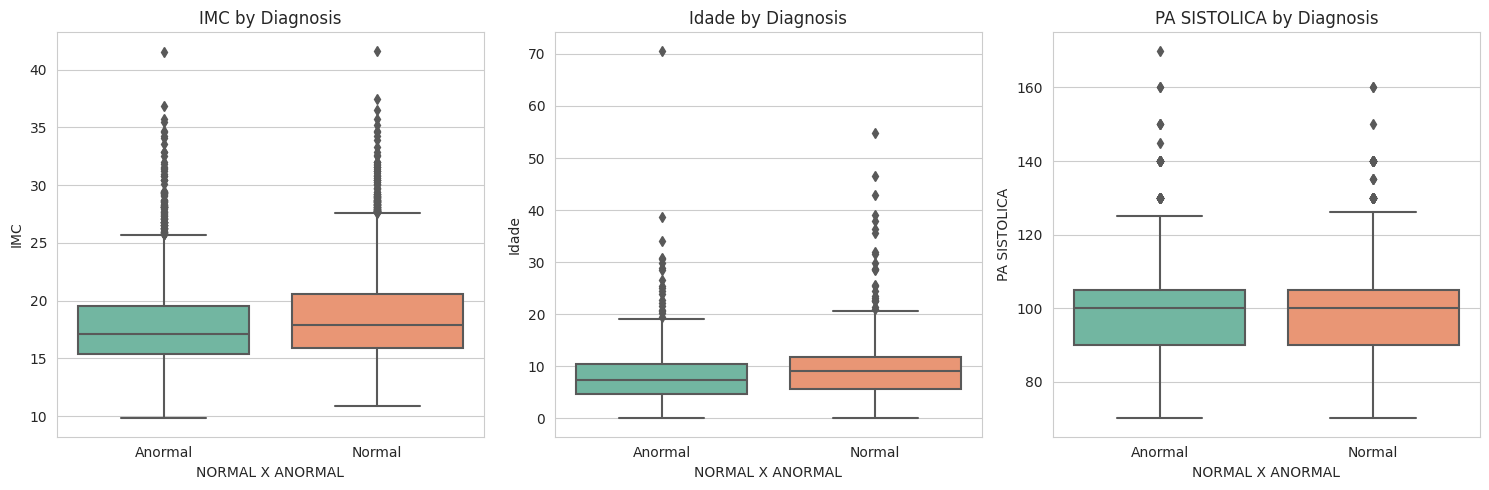

In [69]:
# how numerical features separate the classes
features_to_plot = ['IMC', 'Idade', 'PA SISTOLICA'] 

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='NORMAL X ANORMAL', y=col, data=df, palette='Set2')
    plt.title(f'{col} by Diagnosis')
plt.tight_layout()
plt.show()


--- Analysis for SEXO ---
NORMAL X ANORMAL    Anormal     Normal
SEXO                                  
0.0               35.711672  64.288328
1.0               35.215262  64.784738

--- Analysis for SOPRO_sistólico ---
NORMAL X ANORMAL    Anormal     Normal
SOPRO_sistólico                       
0                  8.615049  91.384951
1                 96.053281   3.946719

--- Analysis for B2_Hiperfonética ---
NORMAL X ANORMAL    Anormal     Normal
B2_Hiperfonética                      
0                 34.794562  65.205438
1                 98.461538   1.538462

--- Analysis for PPA_Pre-Hipertensão PAS ---
NORMAL X ANORMAL           Anormal     Normal
PPA_Pre-Hipertensão PAS                      
0                        35.253027  64.746973
1                        41.764706  58.235294


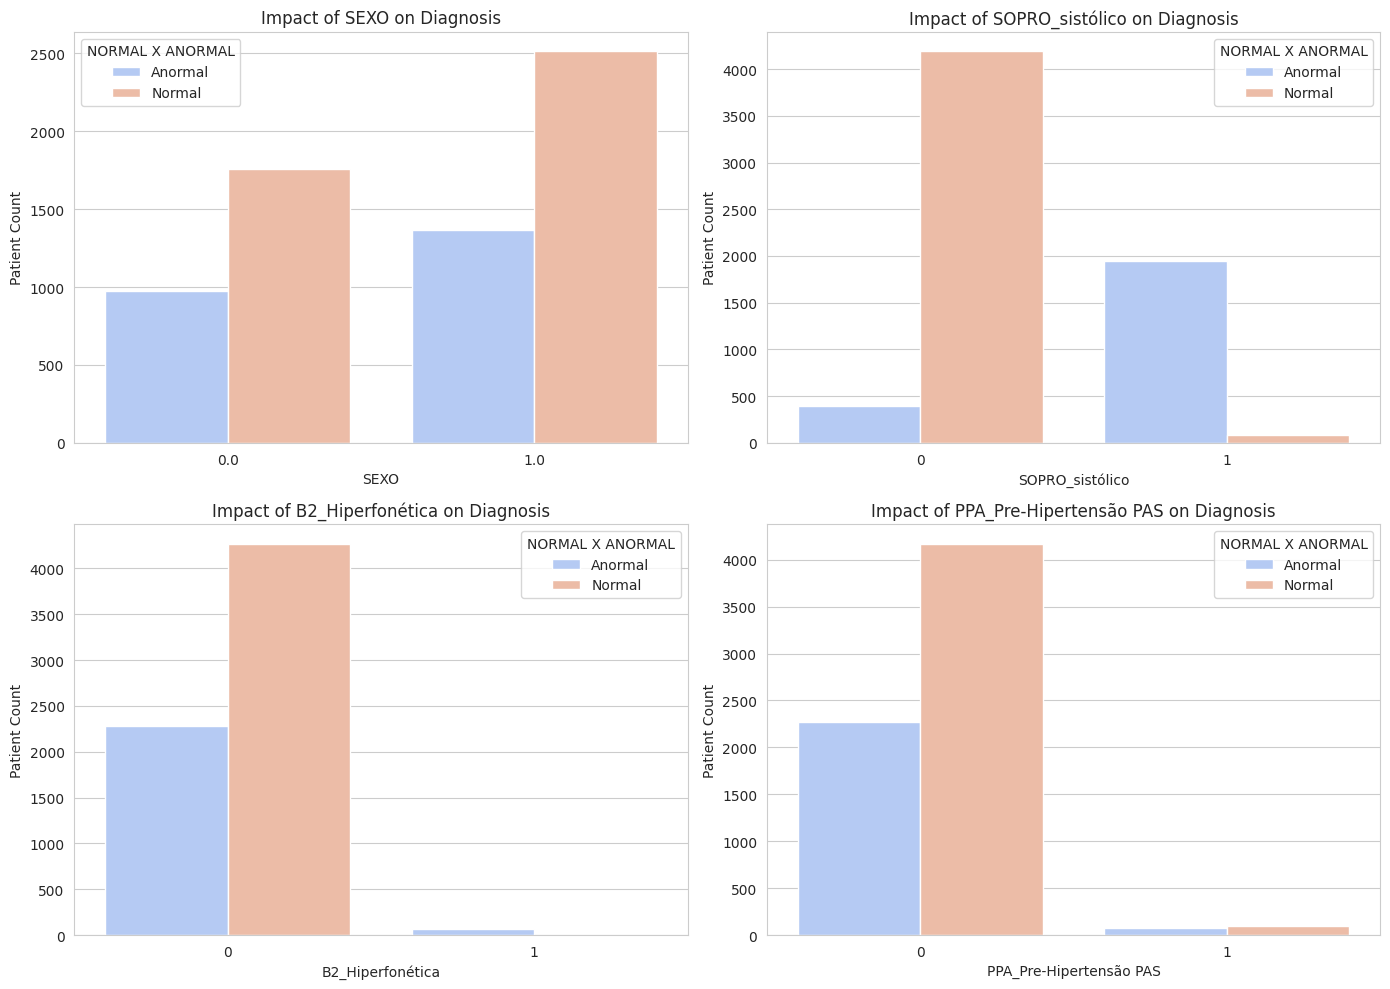

In [70]:


features_to_check = [
    'SEXO',                 # Demographics
    'SOPRO_sistólico',      # The most common Murmur (strong indicator)
    'B2_Hiperfonética',     # Abnormal heart sound (often Pulmonary Hypertension)
    'PPA_Pre-Hipertensão PAS' # Blood Pressure issues
]

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features_to_check):
    plt.subplot(2, 2, i + 1)
    
    if feature in df.columns:
        sns.countplot(x=feature, hue='NORMAL X ANORMAL', data=df, palette='coolwarm')
        plt.title(f'Impact of {feature} on Diagnosis')
        plt.ylabel('Patient Count')
        
        cross_tab = pd.crosstab(df[feature], df['NORMAL X ANORMAL'], normalize='index') * 100
        print(f"\n--- Analysis for {feature} ---")
        print(cross_tab)
    else:
        print(f"Warning: Column '{feature}' not found in dataframe.")

plt.tight_layout()
plt.show()

In [71]:
print("--- RAW COUNTS (How many patients?) ---")

print("\n[SOPRO_sistólico] Counts:")
print(pd.crosstab(df['SOPRO_sistólico'], df['NORMAL X ANORMAL'], margins=True))

print("\n[B2_Hiperfonética] Counts:")
print(pd.crosstab(df['B2_Hiperfonética'], df['NORMAL X ANORMAL'], margins=True))

--- RAW COUNTS (How many patients?) ---

[SOPRO_sistólico] Counts:
NORMAL X ANORMAL  Anormal  Normal   All
SOPRO_sistólico                        
0                     395    4190  4585
1                    1947      80  2027
All                  2342    4270  6612

[B2_Hiperfonética] Counts:
NORMAL X ANORMAL  Anormal  Normal   All
B2_Hiperfonética                       
0                    2278    4269  6547
1                      64       1    65
All                  2342    4270  6612


## Multivariate Analysis

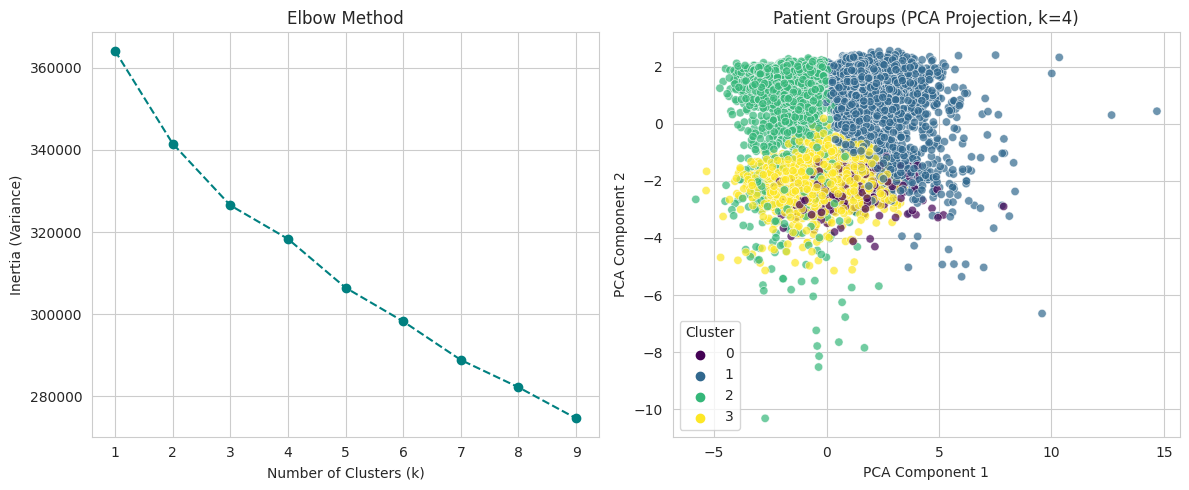

Cluster Profiles (Mean Values):


,Idade,IMC,PA SISTOLICA,PA DIASTOLICA,target,SOPRO_sistólico,PPA_Pre-Hipertensão PAS
Cluster,,,,,,,
0,9.448106,18.334156,101.935780,62.574924,0.302752,0.256881,0.027523
1,12.314681,20.678363,107.030496,66.171598,0.220347,0.174329,0.031862
2,6.032125,16.868592,96.062906,58.647321,0.348356,0.285308,0.016234
3,7.351397,17.634649,99.279853,61.065524,0.553374,0.526026,0.031231


In [72]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


cols_to_exclude = ['NORMAL X ANORMAL', 'target', 'Peso', 'Altura']
X_cluster = df.drop(columns=[c for c in cols_to_exclude if c in df.columns], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Variance)')

k_best = 4
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.7)
plt.title(f'Patient Groups (PCA Projection, k={k_best})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

print("Cluster Profiles (Mean Values):")
profile_cols = ['Idade', 'IMC', 'PA SISTOLICA', 'PA DIASTOLICA', 'target'] 
for col in ['SOPRO_sistólico', 'PPA_Pre-Hipertensão PAS']:
    if col in df.columns: profile_cols.append(col)

display(df.groupby('Cluster')[profile_cols].mean().style.background_gradient(cmap='Reds'))

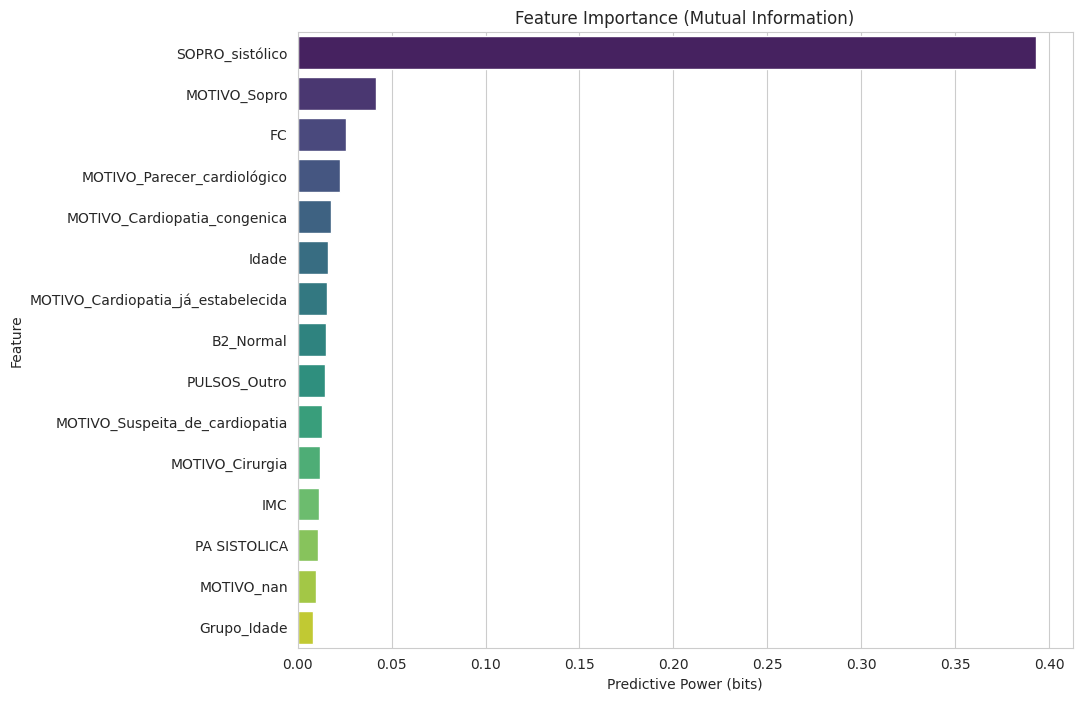

Top 10 Most Important Features:


,Feature,Score
53,SOPRO_sistólico,0.392651
22,MOTIVO_Sopro,0.041566
3,FC,0.026025
27,MOTIVO_Parecer_cardiológico,0.022351
19,MOTIVO_Cardiopatia_congenica,0.017911
5,Idade,0.016296
25,MOTIVO_Cardiopatia_já_estabelecida,0.015666
48,B2_Normal,0.014974
39,PULSOS_Outro,0.014867
16,MOTIVO_Suspeita_de_cardiopatia,0.013153


In [73]:
df_mi = df.dropna(subset=['target']).copy()

drop_cols = ['NORMAL X ANORMAL', 'target', 'Cluster', 'Peso', 'Altura']
X = df_mi.drop(columns=[c for c in drop_cols if c in df_mi.columns], errors='ignore')
y = df_mi['target']

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Score': mi_scores
}).sort_values(by='Score', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Score', y='Feature', data=mi_df.head(15), palette='viridis')
plt.title('Feature Importance (Mutual Information)')
plt.xlabel('Predictive Power (bits)')
plt.show()

print("Top 10 Most Important Features:")
display(mi_df.head(10))

## Predictive Models

In [74]:
from sklearn.model_selection import train_test_split

print(f"Original shape: {df.shape}")
df_clean = df.dropna(subset=['target']).copy()
print(f"Shape after dropping missing targets: {df_clean.shape}")

cols_to_drop = ['NORMAL X ANORMAL', 'target', 'Cluster', 'Peso', 'Altura']
X = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], errors='ignore')
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale the Data (Crucial for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Prepared Successfully.")
print(f"Training Shape: {X_train_scaled.shape}")
print(f"Testing Shape:  {X_test_scaled.shape}")

Original shape: (6621, 59)
Shape after dropping missing targets: (6612, 59)
Data Prepared Successfully.
Training Shape: (4628, 54)
Testing Shape:  (1984, 54)


In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix

df_clean = df.dropna(subset=['target']).copy()

cols_drop = ['NORMAL X ANORMAL', 'target', 'Cluster', 'Peso', 'Altura']
X = df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns], errors='ignore')
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    specificity = tn / (tn + fp)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Sensitivity (Recall)': recall_score(y_test, preds),
        'Specificity': specificity,
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).set_index('Model')

print("### Comprehensive Model Performance ###")
display(results_df.style.background_gradient(cmap='Greens'))

### Comprehensive Model Performance ###


,Accuracy,Sensitivity (Recall),Specificity,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,0.926411,0.833570,0.977361,0.889226,0.915504
SVM (RBF),0.921371,0.829303,0.971897,0.881997,0.927761
Naive Bayes,0.693548,0.159317,0.986729,0.269231,0.910697
Random Forest,0.927923,0.837838,0.977361,0.891749,0.943150


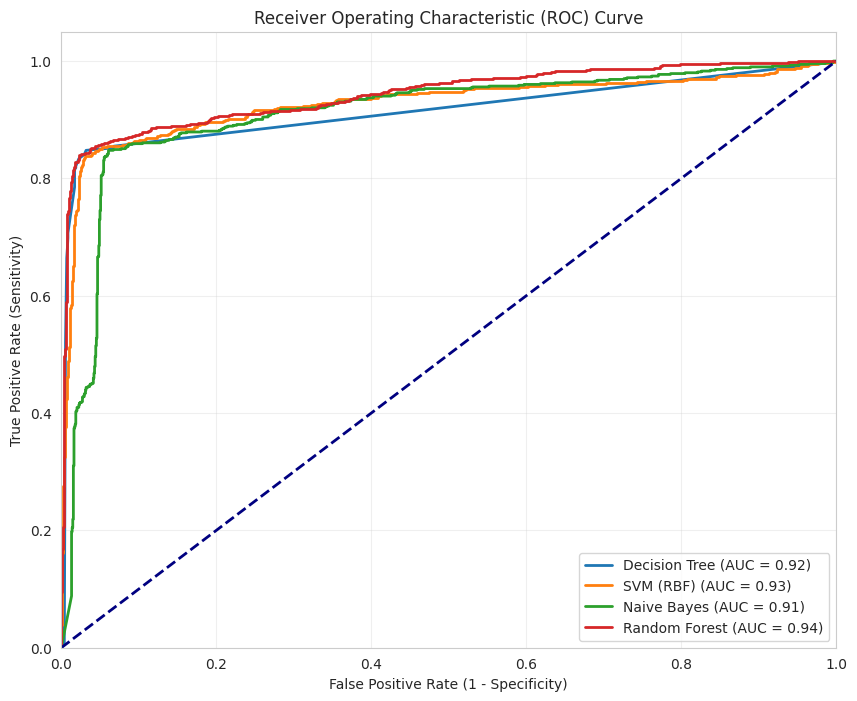

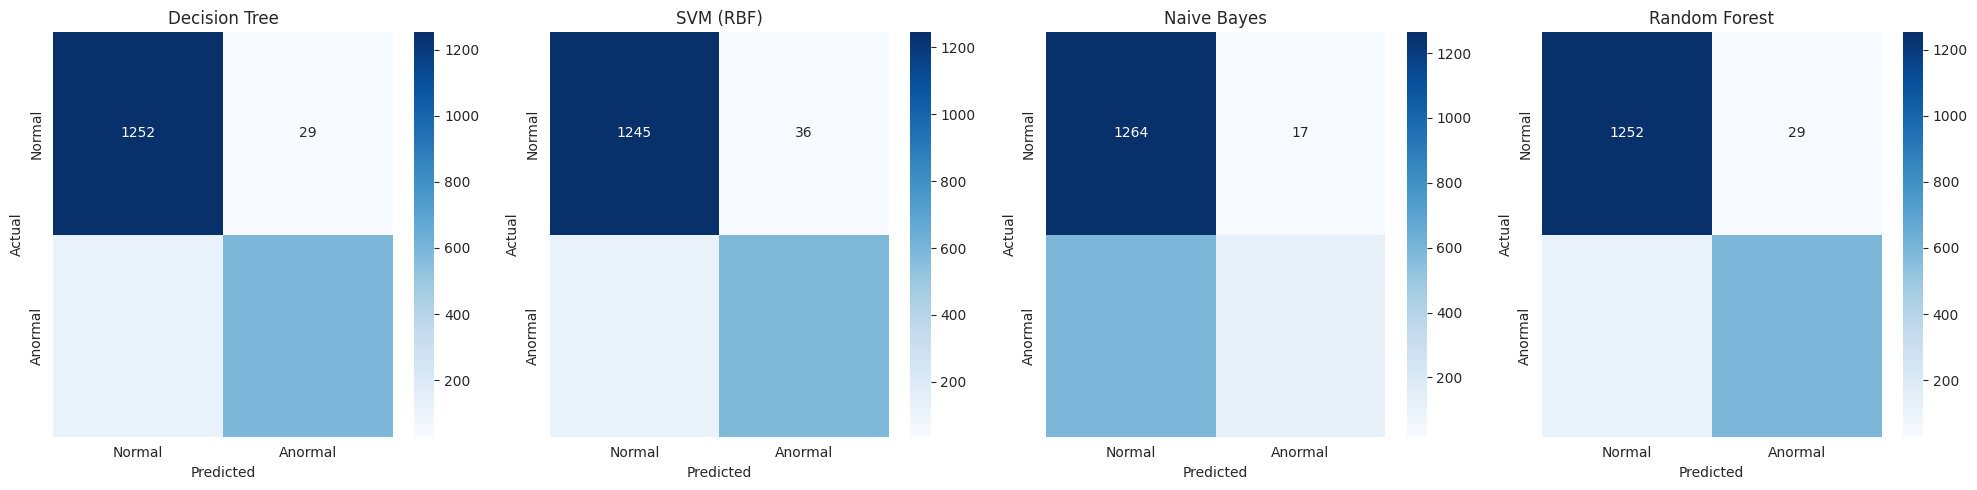

In [76]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anormal'], yticklabels=['Normal', 'Anormal'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### Ablation Results: History Only (No Physical Exam) ###


,Accuracy,Sensitivity (Recall),Specificity,F1-Score,ROC-AUC
Model,,,,,
DT (No Murmur),0.715222,0.345661,0.918033,0.462417,0.732407
SVM (No Murmur),0.724798,0.394026,0.906323,0.503636,0.720147
RF (No Murmur),0.724798,0.389758,0.908665,0.500914,0.752992


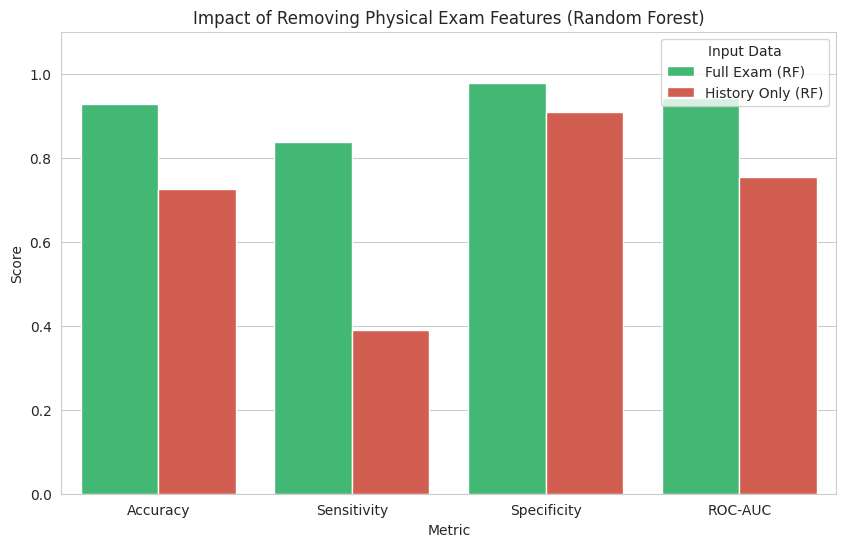

In [77]:

cols_exclude = ['SOPRO_sistólico', 'SOPRO_diastólico', 'SOPRO_contínuo', 
                'SOPRO_sistolico e diastólico', 'MOTIVO_Sopro']
cols_std = ['NORMAL X ANORMAL', 'target', 'Cluster', 'Peso', 'Altura']

X_ns = df_clean.drop(columns=cols_std + cols_exclude, errors='ignore')
y_ns = df_clean['target']

X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_ns, y_ns, test_size=0.3, random_state=42, stratify=y_ns
)

scaler_ns = StandardScaler()
X_train_ns_scaled = scaler_ns.fit_transform(X_train_ns)
X_test_ns_scaled = scaler_ns.transform(X_test_ns)

models_ns = {
    "DT (No Murmur)": DecisionTreeClassifier(max_depth=5, random_state=42),
    "SVM (No Murmur)": SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    "RF (No Murmur)": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results_ns = []

for name, model in models_ns.items():
    model.fit(X_train_ns_scaled, y_train_ns)
    preds = model.predict(X_test_ns_scaled)
    probs = model.predict_proba(X_test_ns_scaled)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test_ns, preds).ravel()
    specificity = tn / (tn + fp)
    
    results_ns.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_ns, preds),
        'Sensitivity (Recall)': recall_score(y_test_ns, preds),
        'Specificity': specificity,
        'F1-Score': f1_score(y_test_ns, preds),
        'ROC-AUC': roc_auc_score(y_test_ns, probs)
    })


df_results_ns = pd.DataFrame(results_ns).set_index('Model')

print("### Ablation Results: History Only (No Physical Exam) ###")
display(df_results_ns.style.background_gradient(cmap='Reds', vmax=1.0))


if 'results_df' in locals():
    best_full_model = results_df.loc['Random Forest']
    best_ns_model = df_results_ns.loc['RF (No Murmur)']
    
    comparison_data = {
        'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'ROC-AUC'],
        'Full Exam (RF)': [best_full_model['Accuracy'], best_full_model['Sensitivity (Recall)'], 
                           best_full_model['Specificity'], best_full_model['ROC-AUC']],
        'History Only (RF)': [best_ns_model['Accuracy'], best_ns_model['Sensitivity (Recall)'], 
                              best_ns_model['Specificity'], best_ns_model['ROC-AUC']]
    }
    
    comp_df = pd.DataFrame(comparison_data).melt(id_vars='Metric', var_name='Scenario', value_name='Score')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Metric', y='Score', hue='Scenario', data=comp_df, palette=['#2ecc71', '#e74c3c'])
    plt.title('Impact of Removing Physical Exam Features (Random Forest)')
    plt.ylim(0, 1.1)
    plt.ylabel('Score')
    plt.legend(title='Input Data')
    plt.show()